In [20]:
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision import transforms


In [29]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

test_transform = transforms.ToTensor()

In [30]:
from torchvision.datasets import CIFAR10

train_data = CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = CIFAR10(
    root="data",
    train=False,
    download=False,
    transform=test_transform
)

In [40]:
train_loader = DataLoader(
    train_data,
    1024,
    True
)
test_loader = DataLoader(
    test_data,
    1024,
    True
)

In [41]:
class alexnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(3,64,3,1,1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64,192,3,1,1),
            nn.ReLU(),
            nn.BatchNorm2d(192),
            nn.MaxPool2d(2),
            nn.Conv2d(192,384,3,1,1),
            nn.ReLU(),
            nn.BatchNorm2d(384),
            nn.Conv2d(384,256,3,1,1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(256,256,3,1,1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2)

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4,1024),
            nn.ReLU(),
            nn.Dropout(p=0.6),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Dropout(p=0.6),
            nn.Linear(512,10)
        )
    def forward(self,x):
        x = self.feature(x)
        x = self.classifier(x)
        return x

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device
model = alexnet().to(device)
device

'cuda'

In [43]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(),lr = 0.001, weight_decay=0.0001)
loss_fn = nn.CrossEntropyLoss()

In [44]:
for i in range(19):
    model.train()
    for image , label in train_loader:
        image = image.to(device)
        label = label.to(device)
        output = model(image)
        optimizer.zero_grad()
        loss = loss_fn(output,label)
        loss.backward()
        optimizer.step()
    print(f"epoch{i} loss:{loss.item()}")

epoch0 loss:1.4461849927902222
epoch1 loss:1.2834042310714722
epoch2 loss:0.9501063227653503
epoch3 loss:0.8760069608688354
epoch4 loss:0.704847514629364
epoch5 loss:0.740527868270874
epoch6 loss:0.5924490690231323
epoch7 loss:0.5896017551422119
epoch8 loss:0.4931771159172058
epoch9 loss:0.5251050591468811
epoch10 loss:0.4161463975906372
epoch11 loss:0.37796077132225037
epoch12 loss:0.4075266420841217
epoch13 loss:0.3496105670928955
epoch14 loss:0.3734647035598755
epoch15 loss:0.318960577249527
epoch16 loss:0.33707094192504883
epoch17 loss:0.29830968379974365
epoch18 loss:0.30071017146110535


In [45]:
model.eval()
correct , total = 0 , 0
with torch.no_grad():
    for images , labels  in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        correct+=(output.argmax(dim=1)==labels).sum().item()
        total+=labels.size(0)
    accuracy = 100* correct/total
    print(f"accuracy :{accuracy}")

accuracy :84.74


In [46]:
torch.save(model.state_dict(),"alexnet_v1.pth")

Total trainable parameters: 6979146


For a more comprehensive summary, including layer-by-layer parameter counts and output shapes, you can use the `torchinfo` library. First, you'd need to install it:

In [48]:
!pip install torchinfo

Then, you can use `summary` from `torchinfo`:

In [49]:
from torchinfo import summary
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
alexnet                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 256, 4, 4]            --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           1,792
│    └─ReLU: 2-2                         [1, 64, 32, 32]           --
│    └─BatchNorm2d: 2-3                  [1, 64, 32, 32]           128
│    └─MaxPool2d: 2-4                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 192, 16, 16]          110,784
│    └─ReLU: 2-6                         [1, 192, 16, 16]          --
│    └─BatchNorm2d: 2-7                  [1, 192, 16, 16]          384
│    └─MaxPool2d: 2-8                    [1, 192, 8, 8]            --
│    └─Conv2d: 2-9                       [1, 384, 8, 8]            663,936
│    └─ReLU: 2-10                        [1, 384, 8, 8]            --
│    └─BatchNorm2d: 2-11                 [1, 384, 8, 8]            768

In [50]:
import matplotlib.pyplot as plt


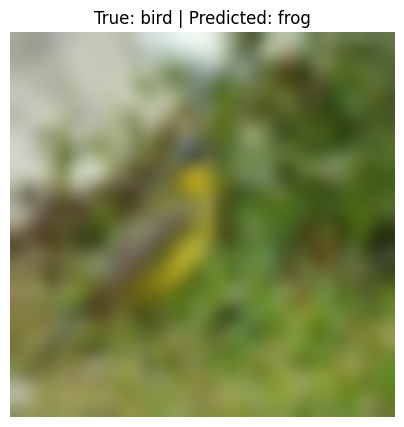

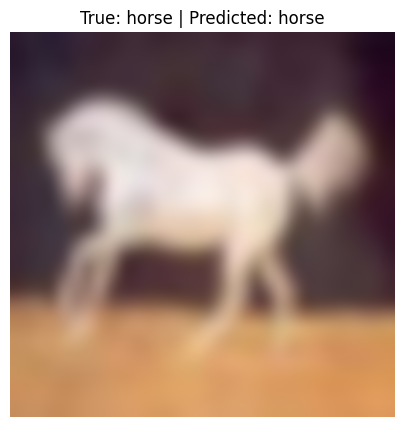

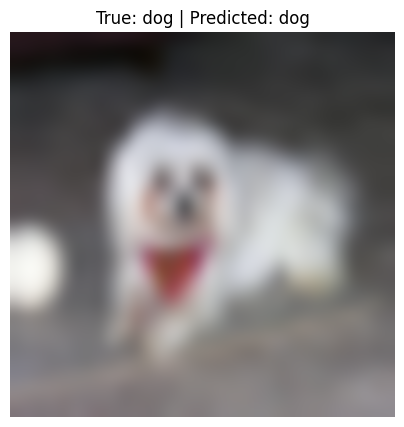

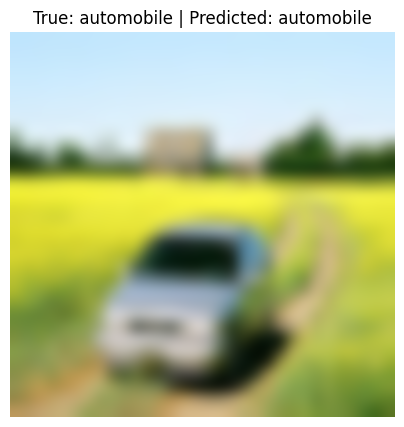

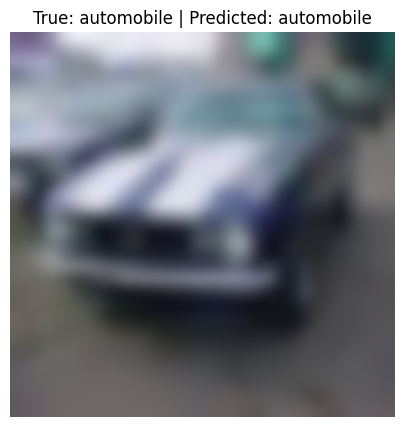

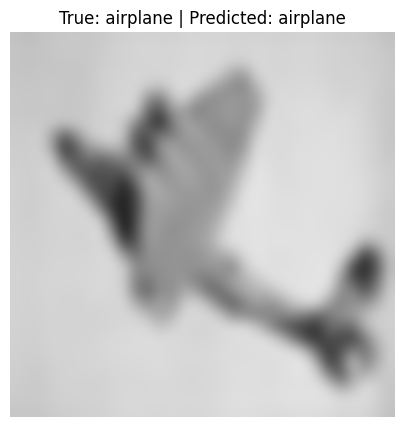

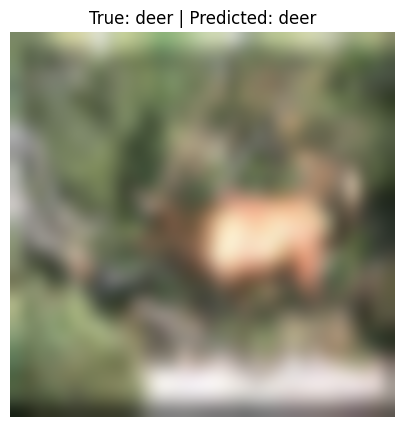

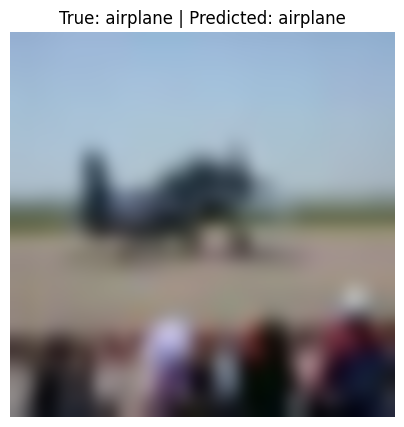

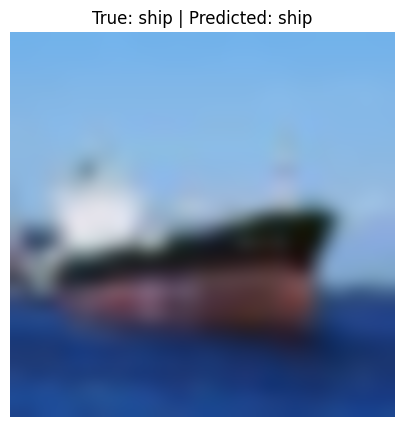

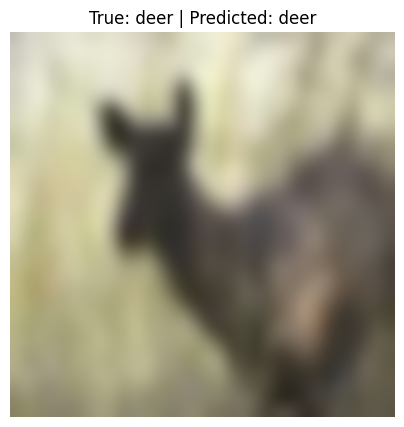